# Notebook 03b: Optimización de la Regresión Logística mediante WoE
# 3b: Optimización de la Regresión Logística mediante WoE

**Objetivo**: r: replicar y tratar de mejorar el modelo de Regresión Logística de Mallo aplicando la transformación Weight of Evidence (WoE) a las variables, que es el tratamiento que Mallo empleó y cuya ausencia en el notebook 03 explica la diferencia de AUC observada respecto a su resultado.

En el notebook 03, la Regresión Logística entrenada sobre las variables originales (con Flags e imputación a cero) alcanzó un AUC de 0,9709 en validación, frente al 0,9758 de Mallo. Esta diferencia tiene una explicación técnica concreta: la regresión logística asume que cada variable predictora mantiene una relación lineal con el riesgo de impago del cliente. Las variables financieras en su forma original no cumplen ese supuesto: su relación con el riesgo no es proporcional a lo largo de todo su rango de valores (por ejemplo, pasar de 0€ a 100€ en cuenta no implica el mismo cambio en el riesgo que pasar de 10.000€ a 10.100€). La transformación WoE resuelve este problema al convertir cada variable en una escala que sí respeta esa proporcionalidad por tramos, de modo que el modelo lineal puede ajustarse correctamente. Mallo aplicó esta transformación antes de ajustar su modelo; en este notebook se reproduce esa misma estrategia.

**Entradas**: *data/train.csv*, *data/val.csv*, *data/test.csv*.

## 3b.1 Importaciones

Se importan las librerías necesarias, incluida *optbinning*, que implementa en Python el binning óptimo y la transformación WoE equivalentes a los del paquete *scorecard* de R empleado por Mallo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from optbinning import BinningProcess
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

SEED = 42
print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 3b.2 Carga de las particiones y peso del oversampling

Se cargan los tres conjuntos generados en el notebook 02 y se reconstruye el peso del sobremuestreo (6 para los buenos, 1 para los malos), idéntico al de los notebooks 03 y 04.

In [2]:
train = pd.read_csv("../data/train.csv")
val   = pd.read_csv("../data/val.csv")
test  = pd.read_csv("../data/test.csv")

FEATURES = [c for c in train.columns if c != "Target_Impago"]
X_train, y_train = train[FEATURES], train["Target_Impago"]
X_val,   y_val   = val[FEATURES],   val["Target_Impago"]
X_test,  y_test  = test[FEATURES],  test["Target_Impago"]

PESO = 6
w_train = np.where(y_train == 0, PESO, 1)

print(f"Train: {X_train.shape[0]:,} | Val: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}")

Train: 8,396 | Val: 4,198 | Test: 4,198


## 3b.3 La transformación Weight of Evidence (WoE): tramado de variables

El **tramado de variables** (*binning*) consiste en dividir el rango de valores de cada variable numérica en intervalos o tramos, agrupando los valores que tienen un comportamiento similar frente al impago.

A cada tramo se le asigna una puntuación llamada **peso de la evidencia** (*Weight of Evidence*, WoE):

$$WOE(I_k) = \ln\left(\frac{\text{Proporción de clientes buenos en el tramo } I_k}{\text{Proporción de clientes malos en el tramo } I_k}\right)$$

La lógica es sencilla: si en un tramo hay muchos más buenos que malos, el cociente es mayor que 1 y el logaritmo es positivo; si hay muchos más malos que buenos, el cociente es menor que 1 y el logaritmo es negativo. El signo indica directamente si el tramo agrupa clientes que tienden a pagar el préstamo (WoE positivo) o clientes que tienden a no pagarlo (WoE negativo).

**Ejemplo con X48 (Meses en descubierto).**
Se divide a los 8.396 clientes en cuatro grupos según los meses que han tenido saldo negativo en sus cuentas. Dentro de cada grupo se cuenta cuántos clientes acabaron pagando (*buenos*, Target = 0) y cuántos acabaron impagando (*malos*, Target = 1):

| Tramo (meses en descubierto) | Buenos | Malos | Tasa de impago | WoE |
|------------------------------|--------|-------|----------------|-----|
| 0 meses | 5.501 clientes | 1.100 clientes | 16,7 % | **+0,89** |
| 1–2 meses | 123 clientes | 367 clientes | 74,9 % | **−1,81** |
| 3–5 meses | 16 clientes | 460 clientes | 96,6 % | **−4,08** |
| 6 o más meses | 1 cliente | 828 clientes | 99,9 % | **−7,44** |

En el tramo "0 meses" hay muchos más buenos que malos, tiene WoE positivo. En el tramo "6 o más meses" casi todos son malos (828 clientes que impagaron frente a 1 solo que pagó), por lo que el cociente buenos/malos es prácticamente 0 y el logaritmo es muy negativo (−7,44). Cuanto más negativo es el WoE, mayor es el riesgo de impago en ese grupo de clientes.

Una vez calculados los WoE de cada tramo, el valor numérico original de cada cliente se sustituye por el WoE del tramo al que pertenece. Por ejemplo: un cliente con X48 = 4 (cuatro meses en descubierto) cae en el tramo "3–5 meses", por lo que su valor 4 se reemplaza por −4,08; un cliente con X48 = 0 cae en el tramo "0 meses" y su valor 0 se reemplaza por +0,89. Es ese número (−4,08 o +0,89) el que entra en la regresión logística, no el valor original.

El **Valor de la Información** (IV) resume en un único número cuánto ayuda cada variable a separar buenos de malos. Cuanto más distintos son los WoE entre tramos, más discrimina la variable y mayor es su IV.

## 3b.4 Binning y transformación de las variables

Mallo aplicó el tramado WoE únicamente a las 7 variables con valores faltantes, porque su objetivo principal era integrar los nulos en el modelo sin descartarlos. En este trabajo los valores faltantes ya fueron resueltos mediante Flags e imputación a cero en el notebook 01, por lo que se opta por aplicar el tramado a las 30 variables en su totalidad: al transformar todas las variables a escala WoE, la regresión logística trabaja sobre una escala homogénea de riesgo en todas ellas, no solo en las que originalmente tenían nulos, lo que maximiza el beneficio de linealización.

El tramado se calcula exclusivamente sobre la muestra de entrenamiento y se aplica después a validación y test. Esto es fundamental para no contaminar la evaluación: si los tramos se aprendieran sobre todos los datos, las particiones de validación y test habrían influido en la transformación.

In [3]:
binning = BinningProcess(FEATURES)
binning.fit(X_train.values, y_train.values)

X_train_woe = binning.transform(X_train.values, metric="woe")
X_val_woe   = binning.transform(X_val.values,   metric="woe")
X_test_woe  = binning.transform(X_test.values,  metric="woe")

# Valor de la Información (IV) de cada variable
iv = binning.summary().sort_values("iv", ascending=False)[["name", "iv"]]
print("Variables con mayor Valor de la Información (IV):")
print(iv.head(10).to_string(index=False))

Variables con mayor Valor de la Información (IV):
                              name        iv
53_Porcentaje_Contratos_Incidencia  4.557275
          48_Meses_Descubierto_12m  3.618214
      3_Saldo_Medio_Pasivo_Liq_12m  1.805029
          5_Saldo_Medio_Pasivo_12m  1.589369
      46_Saldo_Min_Medio_Pasivo_6m  1.213478
       7_Saldo_Min_Pasivo_Vista_1m  1.067723
      8_Rango_Min_Saldo_Pasivo_12m  0.984184
             56_Ratio_Pagos_Pasivo  0.972434
                   15_Deuda_Activo  0.710784
            47_Cuota_Max_Prestamos  0.703422


Las dos variables con mayor IV son X53 (Porcentaje de contratos con incidencia, IV = 4,56) y X48 (Meses en descubierto, IV = 3,62), resultado coherente con las correlaciones detectadas en el EDA y con la importancia de variables obtenida en el notebook 03. La escala habitual de interpretación del IV considera fuerte un valor a partir de 0,3 y, según buena parte de la práctica estándar, deja de ser fiable por encima de 0,5: en ese rango, un IV tan alto suele ser señal de alarma de fuga de información antes que prueba de un buen predictor, porque indica que la variable separa casi perfectamente a buenos y malos por sí sola. X53 y X48 multiplican ese umbral varias veces, lo que confirma, desde la óptica del WoE, la misma sospecha planteada en el notebook 03 y que allí se contrasta de forma empírica. El resto de variables de la tabla sí se mantiene en el rango que cabe interpretar como señal predictiva legítima.

## 3b.5 Regresión Logística sobre las variables WoE

Con las variables ya transformadas a escala WoE (logaritmo de un cociente de proporciones), se ajusta la Regresión Logística. A diferencia del notebook 03, donde las variables tenían escalas muy distintas (euros, meses, ratios entre 0 y 1), aquí todas están expresadas en la misma unidad, por lo que no es necesario estandarizar con StandardScaler. Se aplica igualmente el peso del sobremuestreo y se evalúa el poder discriminante sobre validación y test.

In [4]:
def discriminacion(y, prob):
    auc = roc_auc_score(y, prob)
    fpr, tpr, _ = roc_curve(y, prob)
    ks = (tpr - fpr).max()
    return auc, ks

rl_woe = LogisticRegression(max_iter=5000, random_state=SEED)
rl_woe.fit(X_train_woe, y_train, sample_weight=w_train)

auc_val,  ks_val  = discriminacion(y_val,  rl_woe.predict_proba(X_val_woe)[:, 1])
auc_test, ks_test = discriminacion(y_test, rl_woe.predict_proba(X_test_woe)[:, 1])

print("Regresión Logística + WoE (30 variables)")
print(f"  Validación: AUC = {auc_val:.4f} | KS = {ks_val:.4f}")
print(f"  Test:       AUC = {auc_test:.4f} | KS = {ks_test:.4f}")
print(f"  Mallo (ref. validación): AUC = 0.9758 | KS = 0.8897")

Regresión Logística + WoE (30 variables)
  Validación: AUC = 0.9744 | KS = 0.8891
  Test:       AUC = 0.9805 | KS = 0.8956
  Mallo (ref. validación): AUC = 0.9758 | KS = 0.8897


## 3b.6 Versión parsimoniosa: las 12 variables del modelo de Mallo

Mallo realizó dos etapas de selección de variables. En la primera, redujo las 64 variables originales a 25 aplicando el Valor de la Información, la eliminación de colinealidad y el criterio experto en riesgo de crédito. En la segunda, partiendo de esas 25, aplicó un procedimiento paso a paso (*stepAIC*) que redujo el modelo a 12 variables: ese es su modelo final publicado, denominado *mod12AIC*.

Este modelo se reproduce en Python con dos objetivos. El primero es verificar la fidelidad de la replicación: si nuestro resultado con esas mismas 12 variables es similar al publicado por Mallo en R (AUC = 0,9758), quedará confirmado que la implementación es correcta. El segundo es comparar con el modelo de 30 variables de la sección anterior. Si el rendimiento es equivalente, significa que las 12 variables de Mallo ya concentran la mayor parte de la capacidad discriminante y que ampliar el conjunto no aporta una mejora significativa.

In [5]:
vars_mallo = [
    "8_Rango_Min_Saldo_Pasivo_12m", "19_Antiguedad_Activo_1a", "25_Ratio_Hipoteca",
    "46_Saldo_Min_Medio_Pasivo_6m", "47_Cuota_Max_Prestamos", "48_Meses_Descubierto_12m",
    "49_Antiguedad_Primer_Prestamo", "53_Porcentaje_Contratos_Incidencia",
    "55_Ratio_Pasivo_NoVista_Total", "57_Porcentaje_Riesgo_CIRBE", "58_Edad",
    "63_Recibos_NoBasicos_3m",
]
idx = [FEATURES.index(v) for v in vars_mallo]

rl_m12 = LogisticRegression(max_iter=5000, random_state=SEED)
rl_m12.fit(X_train_woe[:, idx], y_train, sample_weight=w_train)

auc_val_m,  ks_val_m  = discriminacion(y_val,  rl_m12.predict_proba(X_val_woe[:, idx])[:, 1])
auc_test_m, ks_test_m = discriminacion(y_test, rl_m12.predict_proba(X_test_woe[:, idx])[:, 1])

print("Regresión Logística + WoE (12 variables de Mallo)")
print(f"  Validación : AUC = {auc_val_m:.4f} | KS = {ks_val_m:.4f}   [Mallo ref.: AUC = 0.9758 | KS = 0.8897]")
print(f"  Test       : AUC = {auc_test_m:.4f} | KS = {ks_test_m:.4f}")

Regresión Logística + WoE (12 variables de Mallo)
  Validación : AUC = 0.9747 | KS = 0.8950   [Mallo ref.: AUC = 0.9758 | KS = 0.8897]
  Test       : AUC = 0.9784 | KS = 0.9012


La réplica en Python del *mod12AIC* de Mallo obtiene en validación un AUC de 0,9747, frente al 0,9758 publicado por Mallo en R: una diferencia de apenas una milésima, atribuible a variaciones entre implementaciones (distintos algoritmos de tramado en *optbinning* y *scorecard*). En la métrica KS, la réplica (0,8950) supera incluso la referencia original (0,8897). Esta equivalencia confirma que la metodología se ha reproducido con alta fidelidad y que las 12 variables que Mallo seleccionó mediante *stepAIC* concentran efectivamente la mayor parte de la capacidad discriminante del conjunto.

La tabla siguiente reúne los cuatro modelos: la Regresión Logística sin WoE del notebook 03 (base), la versión con WoE sobre las 30 variables (3b.5), la réplica en Python del *mod12AIC* de Mallo con WoE sobre sus 12 variables (3b.6) y el resultado original de Mallo en R como referencia.

                          Modelo  AUC val  KS val AUC test
      RL base (crudo + escalado)   0.9709       -   0.9723
         RL + WoE (30 variables)   0.9744  0.8891   0.9805
RL + WoE (12 variables de Mallo)   0.9747   0.895   0.9784
              Mallo (referencia)   0.9758  0.8897        -


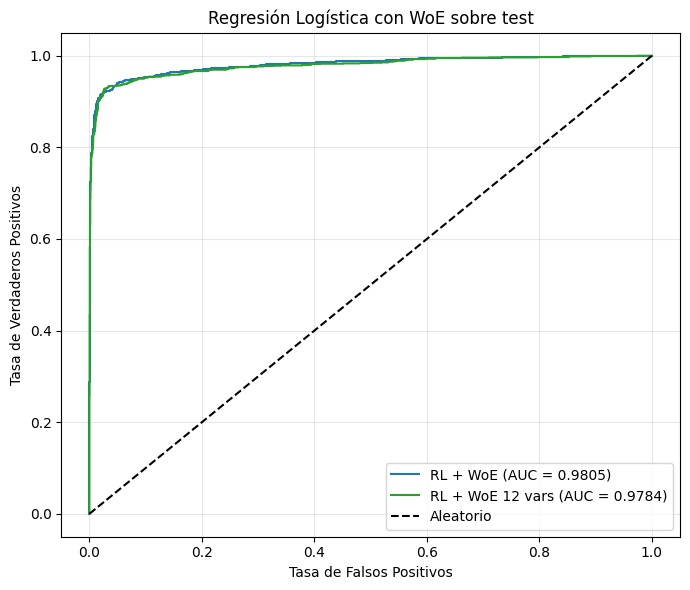

In [6]:
resumen = pd.DataFrame({
    "Modelo": [
        "RL base (crudo + escalado)",
        "RL + WoE (30 variables)",
        "RL + WoE (12 variables de Mallo)",
        "Mallo (referencia)",
    ],
    "AUC val":  [0.9709, round(auc_val, 4),  round(auc_val_m, 4),  0.9758],
    "KS val":   ["-",    round(ks_val, 4),   round(ks_val_m, 4),   0.8897],
    "AUC test": [0.9723, round(auc_test, 4), round(auc_test_m, 4), "-"],
})
print(resumen.to_string(index=False))

# Curvas ROC sobre test: RL base vs RL + WoE
fig, ax = plt.subplots(figsize=(7, 6))
for prob, label, color in [
    (rl_woe.predict_proba(X_test_woe)[:, 1],            f"RL + WoE (AUC = {auc_test:.4f})",   "#1f77b4"),
    (rl_m12.predict_proba(X_test_woe[:, idx])[:, 1],    f"RL + WoE 12 vars (AUC = {auc_test_m:.4f})", "#2ca02c"),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=label, color=color)
ax.plot([0, 1], [0, 1], "k--", label="Aleatorio")
ax.set_xlabel("Tasa de Falsos Positivos")
ax.set_ylabel("Tasa de Verdaderos Positivos")
ax.set_title("Regresión Logística con WoE sobre test")
ax.legend(loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/figures/03b_RL_WoE_ROC.png", dpi=150, bbox_inches="tight")
plt.show()

## 3b.7 Regresión Logística + WoE sobre el conjunto definitivo (sin X53 ni X48)

El notebook 03 concluye, tras contrastar la sospecha de fuga de información de forma empírica, que el resto del estudio debe trabajar sobre el conjunto de 28 variables que excluye X53 y X48. Esa misma decisión se aplica aquí: se repite el tramado WoE y el ajuste de la Regresión Logística sobre esas 28 variables, para obtener el número que se emplea como referencia lineal definitiva en el notebook 04. Los resultados de las secciones anteriores (30 variables y 12 variables de Mallo, ambas con X53 y X48) se conservan como contexto de la replicación, no como resultado final.

In [7]:
FEATURES_FINAL = [c for c in FEATURES if c not in
                   ("53_Porcentaje_Contratos_Incidencia", "48_Meses_Descubierto_12m")]

binning_final = BinningProcess(FEATURES_FINAL)
binning_final.fit(X_train[FEATURES_FINAL].values, y_train.values)

X_train_woe_final = binning_final.transform(X_train[FEATURES_FINAL].values, metric="woe")
X_val_woe_final   = binning_final.transform(X_val[FEATURES_FINAL].values,   metric="woe")
X_test_woe_final  = binning_final.transform(X_test[FEATURES_FINAL].values,  metric="woe")

rl_woe_final = LogisticRegression(max_iter=5000, random_state=SEED)
rl_woe_final.fit(X_train_woe_final, y_train, sample_weight=w_train)

auc_val_final,  ks_val_final  = discriminacion(y_val,  rl_woe_final.predict_proba(X_val_woe_final)[:, 1])
auc_test_final, ks_test_final = discriminacion(y_test, rl_woe_final.predict_proba(X_test_woe_final)[:, 1])

print("Regresión Logística + WoE (28 variables, sin X53 ni X48)")
print(f"  Validación: AUC = {auc_val_final:.4f} | KS = {ks_val_final:.4f}")
print(f"  Test:       AUC = {auc_test_final:.4f} | KS = {ks_test_final:.4f}")

Regresión Logística + WoE (28 variables, sin X53 ni X48)
  Validación: AUC = 0.8960 | KS = 0.6363
  Test:       AUC = 0.9142 | KS = 0.6856


## 3b.8 Conclusión

El modelo base del notebook 03 (Regresión Logística sin WoE, 30 variables) obtuvo un AUC de 0,9709 en validación. La transformación WoE, aplicada sobre esas mismas 30 variables, eleva el AUC a 0,9744: una mejora atribuible exclusivamente al preprocesamiento, ya que el modelo y las variables son idénticos. Con las 12 variables del *mod12AIC* de Mallo el resultado es prácticamente igual (0,9747), lo que indica que las variables adicionales no aportan capacidad discriminante significativa sobre ese conjunto.

De estos resultados se desprenden tres conclusiones concretas.

- **El WoE era la pieza que faltaba para igualar a Mallo, con las mismas variables que él empleó.** Para aislar el efecto del WoE se comparan dos modelos idénticos salvo en ese preprocesamiento, ambos con las 30 variables: sin WoE (notebook 03) el AUC es 0,9709, y con WoE sube a 0,9744. Esa ganancia se debe a que el modelo sin WoE trabajaba con los valores originales de las variables, cuya relación con el riesgo no es lineal. Con el WoE, el AUC queda a poco más de una milésima del 0,9758 de Mallo. En definitiva, el WoE recupera casi toda la diferencia y deja a la Regresión Logística al nivel de Mallo, siempre dentro del conjunto de 30 variables que incluye X53 y X48.

- **La replicación de Mallo es correcta, y comparte su mismo punto ciego.** Para verificar la réplica se comparan dos modelos con las mismas 12 variables y la misma transformación WoE, cambiando solo el lenguaje: nuestro *mod12AIC* en Python alcanza un AUC de 0,9747 en validación (0,9784 en test), frente al 0,9758 que Mallo publicó en R. La coincidencia, hasta la última milésima, confirma que la metodología se ha reproducido con fidelidad. Esa misma coincidencia es, sin embargo, la prueba de que el 0,9758 de Mallo está construido sobre las mismas dos variables (X53 y X48) que el notebook 03 identifica como sospechosas de fuga: replicar su modelo con alta fidelidad significa replicar también esa dependencia, no descartarla.

- **El resultado que se traslada al notebook 04 es el del conjunto sin X53 ni X48.** Sobre las 28 variables que excluyen ambas, la Regresión Logística con WoE obtiene un AUC de 0,8960 en validación y 0,9142 en test (sección 3b.7), sensiblemente por debajo del 0,9744/0,9805 que se obtiene incluyéndolas. Esta caída es la contrapartida lineal de la misma caída que documenta el notebook 03 para Random Forest y XGBoost, y es la cifra que se adopta como referencia de la Regresión Logística optimizada a partir de aquí.

En conjunto, la Regresión Logística con WoE alcanza el techo de lo que un modelo lineal puede extraer de estos datos, con o sin X53 y X48. La comparación con los modelos no lineales Random Forest y XGBoost, sobre el mismo conjunto definitivo de 28 variables, se desarrolla en el notebook 04. La Regresión Logística conserva, no obstante, su ventaja en interpretabilidad y trazabilidad, propiedades especialmente valoradas en el marco regulatorio de Basilea II.